# LAB 02 — N-gram Language Models

Notebook thực nghiệm: thống kê corpus, so sánh unigram/bigram/trigram, MLE/Laplace, perplexity, dự đoán từ tiếp theo và xếp hạng câu. Các nhận xét cá nhân được ghi riêng trong `bài tập.md` để tự hoàn thiện.

In [1]:
from pathlib import Path
import gzip, json, random, re
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
from ngram_lm import NGramLanguageModel, tokenize

SEED = 42
MAX_DOCUMENTS = 10_000
DATA_FILENAME = 'c4-train.00000-of-01024-30K.json.gz'
DATA_CANDIDATES = [Path('../') / DATA_FILENAME, Path('../../') / DATA_FILENAME, Path(DATA_FILENAME)]
DATA_PATH = next((candidate for candidate in DATA_CANDIDATES if candidate.is_file()), None)
if DATA_PATH is None:
    raise FileNotFoundError(f'Không tìm thấy {DATA_FILENAME}; đặt shard C4 ở thư mục cha của lab_02.')
rng = random.Random(SEED)

In [2]:
# Đọc tối đa 10.000 tài liệu, tách câu đơn giản theo dấu câu cuối câu.
documents = []
with gzip.open(DATA_PATH, 'rt', encoding='utf-8') as source:
    for line in source:
        if len(documents) >= MAX_DOCUMENTS:
            break
        record = json.loads(line)
        text = record.get('text', '')
        sentence_texts = re.split(r'(?<=[.!?])\s+', text)
        sentences = [tokenize(part) for part in sentence_texts]
        sentences = [sentence for sentence in sentences if len(sentence) >= 3]
        if sentences:
            documents.append(sentences)

# Chia theo tài liệu trước để tránh các câu cùng tài liệu lọt sang nhiều tập.
rng.shuffle(documents)
n_docs = len(documents)
train_end = int(n_docs * 0.8)
valid_end = int(n_docs * 0.9)
train_documents = documents[:train_end]
valid_documents = documents[train_end:valid_end]
test_documents = documents[valid_end:]
train_sentences = [sentence for doc in train_documents for sentence in doc]
valid_sentences = [sentence for doc in valid_documents for sentence in doc]
test_sentences = [sentence for doc in test_documents for sentence in doc]
print({'documents': n_docs, 'sentences': len(train_sentences)+len(valid_sentences)+len(test_sentences),
       'train_documents': len(train_documents), 'validation_documents': len(valid_documents),
       'test_documents': len(test_documents)})

{'documents': 10000, 'sentences': 199262, 'train_documents': 8000, 'validation_documents': 1000, 'test_documents': 1000}


In [3]:
def flatten(sentences):
    return [token for sentence in sentences for token in sentence]

train_tokens = flatten(train_sentences)
valid_tokens = flatten(valid_sentences)
test_tokens = flatten(test_sentences)
train_vocab = set(train_tokens)
train_counts = {n: Counter(tuple(s[i:i+n]) for s in train_sentences for i in range(len(s)-n+1)) for n in (1, 2, 3)}
corpus_stats = pd.DataFrame([
    {'metric': 'documents', 'value': n_docs},
    {'metric': 'sentences', 'value': len(train_sentences)+len(valid_sentences)+len(test_sentences)},
    {'metric': 'tokens_total', 'value': len(train_tokens)+len(valid_tokens)+len(test_tokens)},
    {'metric': 'vocabulary_train', 'value': len(train_vocab)},
    *[{'metric': f'unique_{n}gram', 'value': len(train_counts[n])} for n in (1,2,3)],
    *[{'metric': f'one_count_{n}gram', 'value': sum(c == 1 for c in train_counts[n].values())} for n in (1,2,3)],
])
display(corpus_stats)

,metric,value
0,documents,10000
1,sentences,199262
2,tokens_total,3661323
3,vocabulary_train,84197
4,unique_1gram,84197
5,unique_2gram,980780
6,unique_3gram,1945612
7,one_count_1gram,37397
8,one_count_2gram,721163
9,one_count_3gram,1723177


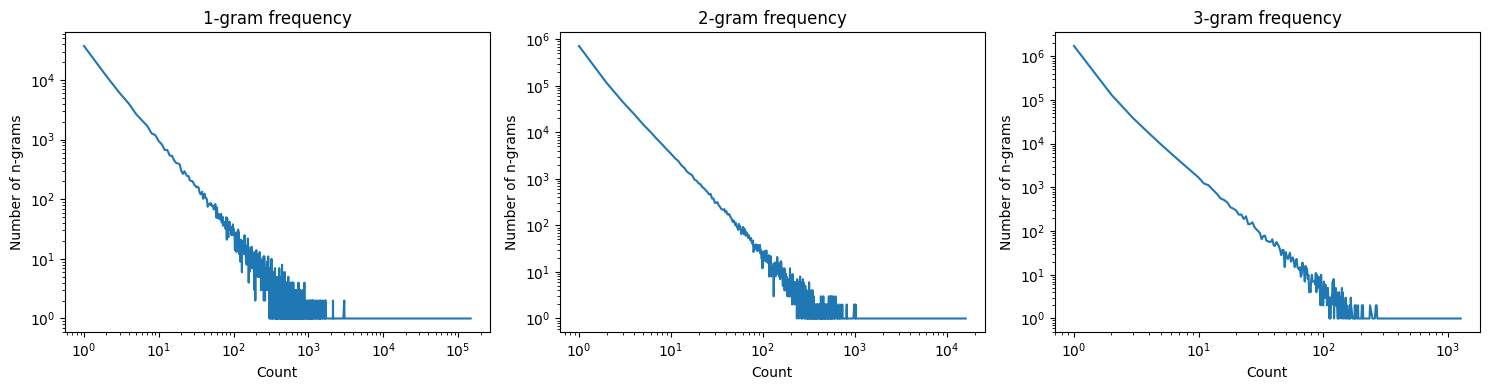

In [4]:
# Phân phối tần suất: trục x là số lần xuất hiện, trục y là số n-gram có tần suất đó.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for axis, n in zip(axes, (1, 2, 3)):
    frequencies = Counter(train_counts[n].values())
    xs = sorted(frequencies)
    axis.plot(xs, [frequencies[x] for x in xs])
    axis.set_xscale('log'); axis.set_yscale('log')
    axis.set_title(f'{n}-gram frequency')
    axis.set_xlabel('Count'); axis.set_ylabel('Number of n-grams')
plt.tight_layout()

In [5]:
models = {n: NGramLanguageModel(n, 'mle').fit(train_sentences) for n in (1, 2, 3)}

def evaluate(model, split):
    return model.perplexity(split)

rows = []
for n, model in models.items():
    for smoothing in ('mle', 'laplace'):
        model.smoothing = smoothing
        rows.append({'model': f'{n}-gram', 'smoothing': smoothing,
                     'train_ppl': evaluate(model, train_sentences),
                     'valid_ppl': evaluate(model, valid_sentences),
                     'test_ppl': evaluate(model, test_sentences)})
    model.smoothing = 'laplace'
perplexity_results = pd.DataFrame(rows).sort_values(['model','smoothing'])
display(perplexity_results)

,model,smoothing,train_ppl,valid_ppl,test_ppl
1,1-gram,laplace,1957.579168,2.157993e+03,1.990664e+03
0,1-gram,mle,1947.731540,inf,inf
3,2-gram,laplace,5480.999647,7.860843e+03,7.395222e+03
2,2-gram,mle,145.524100,inf,inf
5,3-gram,laplace,19387.038575,3.387930e+04,3.343214e+04
4,3-gram,mle,13.086698,inf,inf


In [6]:
# Bảng so sánh perplexity unigram/bigram/trigram trên cùng ba tập.
order_rows = []
for n in (1, 2, 3):
    model = models[n]
    order_rows.append({'model': f'{n}-gram Laplace',
                       'train_ppl': model.perplexity(train_sentences),
                       'validation_ppl': model.perplexity(valid_sentences),
                       'test_ppl': model.perplexity(test_sentences)})
order_comparison = pd.DataFrame(order_rows)
display(order_comparison)

,model,train_ppl,validation_ppl,test_ppl
0,1-gram Laplace,1957.579168,2157.992993,1990.663676
1,2-gram Laplace,5480.999647,7860.842966,7395.221890
2,3-gram Laplace,19387.038575,33879.303227,33432.137290


In [7]:
# Next-word prediction cho 5 context xuất hiện trong validation, kèm từ theo sau thường gặp nhất.
bigram = models[2]
context_counts = Counter()
following_counts = {}
for sentence in valid_sentences:
    for i in range(len(sentence)-2):
        context = tuple(sentence[i:i+2])
        context_counts[context] += 1
        following_counts.setdefault(context, Counter())[sentence[i+2]] += 1
preferred = [('the','cat'), ('natural','language'), ('machine','learning'), ('in','the'), ('one','of')]
contexts = [pair for pair in preferred if pair in context_counts]
for pair, _ in context_counts.most_common():
    if pair not in contexts:
        contexts.append(pair)
    if len(contexts) == 5:
        break
prediction_rows = []
for pair in contexts[:5]:
    context = ' '.join(pair)
    prediction = bigram.predict_next(context, 1)[0]
    actual = following_counts[pair].most_common(1)[0][0]
    prediction_rows.append({'context': context, 'top_prediction': prediction[0],
                            'top_probability': prediction[1], 'actual_next': actual})
prediction_results = pd.DataFrame(prediction_rows)
display(prediction_results)

,context,top_prediction,top_probability,actual_next
0,machine learning,and,0.000554,and
1,in the,most,0.006706,server
2,one of,the,0.103060,the
3,of the,most,0.006706,most
4,to the,most,0.006706,next


In [8]:
# Xếp hạng continuation theo xác suất có điều kiện trên context.
context = 'machine learning'
candidates = ['is useful for NLP', 'banana computer quickly', 'studies language models']
rank_rows = []
for candidate in candidates:
    history = tokenize(context)
    continuation = tokenize(candidate)
    conditional_log_probability = 0.0
    for word in continuation:
        probability = bigram.probability(history[-1:], word)
        conditional_log_probability += __import__('math').log(probability) if probability else float('-inf')
        history.append(word)
    rank_rows.append({'context': context, 'candidate': candidate,
                      'log_probability': conditional_log_probability,
                      'mean_log_probability': conditional_log_probability / max(1, len(continuation)),
                      'continuation_length': len(continuation)})
ranking_results = pd.DataFrame(rank_rows).sort_values('mean_log_probability', ascending=False)
display(ranking_results)

,context,candidate,log_probability,mean_log_probability,continuation_length
0,machine learning,is useful for NLP,-36.920338,-9.230085,4
1,machine learning,banana computer quickly,-34.037030,-11.345677,3
2,machine learning,studies language models,-34.039062,-11.346354,3


In [9]:
# Lưu số liệu thô để results.csv đồng bộ với lần chạy notebook.
all_results = []
for row in perplexity_results.to_dict('records'):
    all_results.append({'section':'mle_vs_laplace', **row})
for row in corpus_stats.to_dict('records'):
    all_results.append({'section':'corpus_stats', **row})
for row in prediction_results.to_dict('records'):
    all_results.append({'section':'next_word', **row})
for row in ranking_results.to_dict('records'):
    all_results.append({'section':'sentence_ranking', **row})
pd.DataFrame(all_results).to_csv('results.csv', index=False)
print('Đã lưu results.csv')

Đã lưu results.csv


# Giải thích kết quả thí nghiệm

## Experiment 1

Khi tăng từ unigram lên bigram và trigram, số lượng n-gram duy nhất tăng rõ rệt. Đồng thời số n-gram chỉ xuất hiện một lần cũng nhiều hơn, cho thấy dữ liệu ngày càng thưa khi context dài hơn. Biểu đồ tần suất cũng thể hiện phần lớn n-gram có tần suất thấp.

## Experiment 2

MLE cho kết quả tốt trên tập train nhưng có thể gặp perplexity bằng `inf` trên validation hoặc test do xuất hiện các n-gram chưa từng thấy trong tập train.

Laplace smoothing giúp tránh xác suất bằng 0 và làm perplexity hữu hạn. Tuy nhiên, perplexity có thể cao hơn vì xác suất được phân phối lại cho cả các n-gram chưa xuất hiện.

## Experiment 3

Khi tăng n, training perplexity có thể giảm vì mô hình học chi tiết hơn từ dữ liệu train. Tuy nhiên, validation và test không nhất thiết tốt hơn do sparsity và unseen n-gram.

Trigram dễ bị overfitting hơn nếu corpus chưa đủ lớn, trong khi unigram và bigram thường ổn định hơn trên dữ liệu mới.

## Context dài hơn có luôn tốt hơn không?

Không. Context dài hơn giúp mô hình sử dụng nhiều thông tin hơn nhưng cũng làm tăng sparsity và số unseen n-gram.

Kết quả thí nghiệm cho thấy mô hình có context dài có thể tốt trên training set nhưng không đảm bảo tốt hơn trên validation và test.
